<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# Exercise Set 1 - 3 - A Different Loss

In this notebook you will learn how to customize the loss function that is used to fit a model to data. If the choice of the loss function does not align with the problem we want to solve,
we might end up with a model that has very low loss values, but is still behind our expectations.

We reconsider the bike rental problem with a different loss function. For the bike rental problem, we could say we have two kinds of errors: 

1. Prepare more bikes than necessary.
2. Prepare fewer bikes than necessary.

Let again $t = h_{\pmb{\theta}}(x) := \theta_0 + \theta_1 x$ be the number of bikes we make ready depending on the (forecast) temperature $x = x_1$.

 1. If the demand $y$ exceeds the number of bikes made ready $t$, we incurr costs $5(y-t)$ for the lost revenue.
 2. If the bikes made ready $t$ exceed the demand $y$, we incurr costs $t-y$ for making the superfluous bikes ready.
 
Therefore, we *weight* both errors differently. 

We seek to find a $\pmb{\theta}$ that minimizes 
 $$L(\pmb{\theta}) = \frac{1}{m} \sum_{i=1}^m \ell(y_i, h_{\pmb{\theta}}(x^{(i)})),$$
where
$$ \ell(t, y) = 5 \cdot \texttt{relu}(y-t) + \texttt{relu}(t-y)$$
and 
$$\texttt{relu}(z):= \max\{z, 0\}$$
is the so-called *rectified linear unit*:

<img src="../activ-relu.png" width="400"/>

Relu is a commonly used activation function and part of PyTorch: [torch.relu](https://pytorch.org/docs/stable/generated/torch.nn.functional.relu.html#torch.nn.functional.relu).

### 1. Implement $\ell(t,y)$ with TensorFlow functions.

In [19]:
# First import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

Define the function ```ell``` to be used below.  
Tipps: [torch.relu](https://pytorch.org/docs/stable/generated/torch.nn.functional.relu.html#torch.nn.functional.relu)

In [20]:
def ell(t,y):
    '''
        Input: y and t are tensors of the same size.
        Output: tensor of 5 * relu(y-t) + relu(t-y) applied to each component of y and t
    '''
    # ADD YOUR CODE HERE, 1 line, replace this line
    return torch.zeros_like(y)


In [21]:
np.random.seed(1)  # set seed for reproducibility
t1 = torch.tensor(np.random.randint(low=0, high=5, size=4), dtype=torch.float64)  # bikes ready
y1 = torch.tensor(np.random.randint(low=0, high=8, size=4), dtype=torch.float64)  # bike demand

losses = ell(t1, y1)
print("t =", t1.numpy(),
      "\ny =", y1.numpy(),
      "\nlosses =", losses.numpy())

t = [3. 4. 0. 1.] 
y = [3. 5. 7. 0.] 
losses = [0. 0. 0. 0.]


**Solution:**
```
t = [3. 4. 0. 1.] 
y = [3. 5. 7. 0.] 
losses = [ 0.  5. 35.  1.]
```

## 2. Make PyTorch use your loss
 1. Below code is a copy of the relevant parts from todays lecture. First, execute everything as is, e.g. using Kernel -> Restart Kernel and Run All Cells.
 2. Go to the function ```train_step``` and replace your own loss function where the code is marked YOUR CODE HERE.


In [22]:
# load the training data from the table file to a pandas data frame
df = pd.read_csv("../bikes-summerdays.tbl", sep=r'\s+')
df['count'] = df['count'].astype(float) # convert count data to floats
m, n_cols = df.shape # training set size and number of columns

In [23]:
def scatterplot_rentals():
    ''' Plot the bike rental counts versus the temperature.'''
    _, ax = plt.subplots()
    ax.scatter(df["temp"], df["count"])
    plt.title("bike rentals versus temperature")
    plt.xlabel('temperature [' + r'$^\circ$' + 'C]')
    plt.ylabel('rental count per hour');
    return ax

### Create Data Matrix $X$ and response vector $y$

In [24]:
# extract response vector
y_train = np.array(df['count']) 

# extract feature columns
n = n_cols - 1 # number of features
temps = np.array(df.loc[:, df.columns != 'count']) # matrix of all other columns (here only one col)

# make data matrix X
X_train = np.ones((m, n+1)) # initialize with all ones
X_train[:,1:n+1] = temps / 10 - 2.5 # normalize temperatures so they are roughly in [-1,1] 

### Training

#### Define your own loss function here
*Tip:* [torch.mean](https://pytorch.org/docs/stable/generated/torch.mean.html)

In [25]:
# just for comparison, define the mean squared error loss
mse_loss = torch.nn.MSELoss(reduction='mean')

def loss_fkt(y_pred, y_true):
    ''' Returns the mean loss according to function ell'''
    # YOUR CODE HERE, replace the following line with a call to your own loss function ell
    # REMEMBER TO take the average, too, so E is a scalar.
    E = mse_loss(y_pred, y_true)
    # END OF YOUR CODE
    return E

#### Test of ```loss_fkt```

In [26]:
np.random.seed(1)
t1 = torch.tensor(np.random.randint(low=0, high=5, size=4), dtype=torch.float64) # bikes ready
y1 = torch.tensor(np.random.randint(low=0, high=8, size=4), dtype=torch.float64) # bike demand

E = loss_fkt(t1, y1)
print("t =", t1.numpy(),
      "\ny =", y1.numpy(),
      "\nE =", E.item())

t = [3. 4. 0. 1.] 
y = [3. 5. 7. 0.] 
E = 12.75


**Solution:**
```
t = [3. 4. 0. 1.] 
y = [3. 5. 7. 0.] 
E = 10.25
```

In [27]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float64)
y_train_tensor = torch.tensor(y_train, dtype=torch.float64).view(-1, 1)  # shape (m, 1)

In [28]:
model = torch.nn.Linear(2, 1, bias=False).double()  # 2 input features, 1 output neuron, no bias

In [29]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.8)

In [30]:
# Create a TensorDataset and DataLoader for batching
dataset = TensorDataset(X_train_tensor, y_train_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [31]:
# training loop
epochs = 200
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_X, batch_y in dataloader:
        optimizer.zero_grad()
        y_pred = model(batch_X)
        # YOUR CODE HERE
        # replace the MSE below with your own loss function
        loss = mse_loss(y_pred, batch_y)
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch_y)
    epoch_loss /= len(dataset)
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss}")

Epoch 1/200 - loss: 44571.755279227116
Epoch 10/200 - loss: 27267.06668099119
Epoch 20/200 - loss: 27243.484938631806
Epoch 30/200 - loss: 27316.224330908342
Epoch 40/200 - loss: 27301.31408047896
Epoch 50/200 - loss: 27303.67776084619
Epoch 60/200 - loss: 27276.051753502314
Epoch 70/200 - loss: 27266.07065205214
Epoch 80/200 - loss: 27274.56690434703
Epoch 90/200 - loss: 27268.142443665118
Epoch 100/200 - loss: 27285.851130983607
Epoch 110/200 - loss: 27272.28910388838
Epoch 120/200 - loss: 27293.020898940427
Epoch 130/200 - loss: 27280.58825799916
Epoch 140/200 - loss: 27291.645849713044
Epoch 150/200 - loss: 27223.80919165297
Epoch 160/200 - loss: 27323.26231419823
Epoch 170/200 - loss: 27309.276962651726
Epoch 180/200 - loss: 27348.77577097273
Epoch 190/200 - loss: 27226.06102580413
Epoch 200/200 - loss: 27311.730873854274


In [34]:
theta = model.weight.detach().numpy()
print("theta:\n", theta)

y_pred = model(X_train_tensor).detach().numpy().flatten()
print("Loss =", loss_fkt(model(X_train_tensor), y_train_tensor).item())

theta:
 [[313.30878999 115.71605119]]
Loss = 27228.470321495595


## Plot predictions

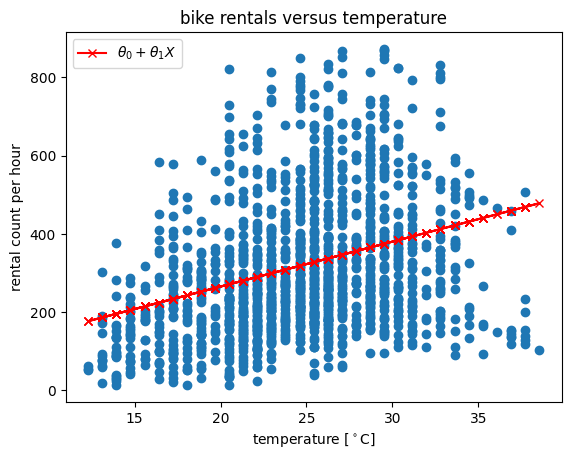

In [ ]:
# draw the same scatterplot as above
ax = scatterplot_rentals()

# now add the predictions, here a regression line
ax.plot(temps, y_pred, 'rx-', label=r"$\theta_0 + \theta_1 X$") # - draws line connecting (r)ed crosses (x)
ax.legend(loc = 'upper left');

After you have solved the exercise correctly, the regression line will have moved up a bit compared to the regular regression line (ending above 600 bikes at maximal temperature). This is due to the fact that the differences to the $y$-values above the line are penalized more. 